# Data Preparation & Purchase Propensity Model

Loads and cleans the UCI Online Retail II dataset, engineers customer-level features, then trains a calibrated purchase propensity classifier.

**Part A:** Data extraction + feature engineering → `data/raw/clv_data.csv`
**Part B:** 4-model comparison + Optuna tuning + probability calibration → `models/purchase_propensity_model.pkl`, `data/processed/stage1_scored.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    log_loss,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

## Part A: Data Extraction & Feature Engineering

Loads and cleans the UCI Online Retail II dataset, computes customer-level features for CLV prediction.

- **Source:** [UCI ML Repository](https://archive.ics.uci.edu/dataset/502/online+retail+ii)
- **Output:** `data/raw/clv_data.csv`

### 1. Load Raw Data

In [2]:
# Load both sheets from the Excel file and concatenate
sheet1 = pd.read_excel('../data/raw/online_retail_II.xlsx', sheet_name='Year 2009-2010')
sheet2 = pd.read_excel('../data/raw/online_retail_II.xlsx', sheet_name='Year 2010-2011')

df_raw = pd.concat([sheet1, sheet2], ignore_index=True)

print(f"Sheet 1 (2009-2010): {len(sheet1):,} rows")
print(f"Sheet 2 (2010-2011): {len(sheet2):,} rows")
print(f"Combined: {len(df_raw):,} rows")
print(f"\n=== Dtypes ===")
print(df_raw.dtypes)
print(f"\n=== Missing Values ===")
print(df_raw.isna().sum())
print(f"\n=== Sample ===")
df_raw.head()

Sheet 1 (2009-2010): 525,461 rows
Sheet 2 (2010-2011): 541,910 rows
Combined: 1,067,371 rows

=== Dtypes ===
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

=== Missing Values ===
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

=== Sample ===


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


### 2. Data Cleaning

In [3]:
rows_before = len(df_raw)
df = df_raw.copy()

# --- Step 1: Convert Invoice to string for cancellation detection ---
df['Invoice'] = df['Invoice'].astype(str).str.strip()

# --- Step 2: Flag cancellations (Invoice starts with 'C') ---
df['is_cancellation'] = df['Invoice'].str.startswith('C')
n_cancellations = df['is_cancellation'].sum()
print(f"Cancellations detected: {n_cancellations:,} rows ({n_cancellations / len(df):.1%})")

# --- Step 3: Save cancellation counts per customer BEFORE removing them ---
cancel_mask = df['is_cancellation'] & df['Customer ID'].notna()
cancellation_counts = (
    df[cancel_mask]
    .groupby('Customer ID')['Invoice']
    .nunique()
    .rename('cancellation_orders')
)
print(f"Customers with cancellations: {len(cancellation_counts):,}")

total_orders_with_cancellations = (
    df[df['Customer ID'].notna()]
    .groupby('Customer ID')['Invoice']
    .nunique()
    .rename('total_orders_incl_cancellations')
)

# --- Step 4: Drop rows with null Customer ID ---
n_null_cust = df['Customer ID'].isna().sum()
df = df[df['Customer ID'].notna()].copy()
df['Customer ID'] = df['Customer ID'].astype(int)
print(f"Dropped null Customer ID: {n_null_cust:,} rows ({n_null_cust / rows_before:.1%})")

# --- Step 5: Remove cancellations ---
n_before_cancel = len(df)
df = df[~df['is_cancellation']].copy()
print(f"Removed cancellations: {n_before_cancel - len(df):,} rows")

# --- Step 6: Remove rows with Quantity <= 0 or Price <= 0 ---
n_before_qty = len(df)
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)].copy()
print(f"Removed non-positive Quantity/Price: {n_before_qty - len(df):,} rows")

# --- Step 7: Remove non-product StockCodes ---
non_product_codes = {'POST', 'DOT', 'M', 'BANK CHARGES', 'PADS', 'S', 'CRUK',
                     'AMAZONFEE', 'D', 'C2', 'DCGS', 'DCGSSBOY', 'DCGSSGIRL',
                     'SP1002', 'gift_0001_10', 'gift_0001_20', 'gift_0001_30',
                     'gift_0001_40', 'gift_0001_50'}
is_alpha_short = df['StockCode'].astype(str).str.match(r'^[A-Za-z]{1,5}$')
is_known_non_product = df['StockCode'].astype(str).str.upper().isin(
    {code.upper() for code in non_product_codes}
)
non_product_mask = is_alpha_short | is_known_non_product
n_non_product = non_product_mask.sum()
df = df[~non_product_mask].copy()
print(f"Removed non-product StockCodes: {n_non_product:,} rows")

# --- Step 8: Deduplicate ---
n_before_dedup = len(df)
df = df.drop_duplicates().copy()
print(f"Removed duplicates: {n_before_dedup - len(df):,} rows")

# --- Step 9: Compute line_total ---
df['line_total'] = df['Quantity'] * df['Price']

# --- Drop helper column ---
df = df.drop(columns=['is_cancellation'])

# --- Summary ---
print(f"\n{'='*50}")
print(f"Rows before cleaning: {rows_before:,}")
print(f"Rows after cleaning:  {len(df):,} ({len(df)/rows_before:.1%} retained)")
print(f"Unique customers:     {df['Customer ID'].nunique():,}")
print(f"Unique invoices:      {df['Invoice'].nunique():,}")
print(f"Date range:           {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")

Cancellations detected: 19,494 rows (1.8%)
Customers with cancellations: 2,572
Dropped null Customer ID: 243,007 rows (22.8%)
Removed cancellations: 18,744 rows
Removed non-positive Quantity/Price: 71 rows
Removed non-product StockCodes: 2,872 rows
Removed duplicates: 26,055 rows

Rows before cleaning: 1,067,371
Rows after cleaning:  776,622 (72.8% retained)
Unique customers:     5,861
Unique invoices:      36,639
Date range:           2009-12-01 07:45:00 to 2011-12-09 12:50:00


### 3. Temporal Split

In [4]:
# Temporal boundaries: ~6 months before end of dataset
calibration_end = pd.Timestamp('2011-06-09')
cutoff_date = pd.Timestamp('2011-12-09')

calibration = df[df['InvoiceDate'] < calibration_end].copy()
holdout = df[(df['InvoiceDate'] >= calibration_end) & (df['InvoiceDate'] < cutoff_date)].copy()

cal_customers = set(calibration['Customer ID'].unique())
hold_customers = set(holdout['Customer ID'].unique())
overlap = cal_customers & hold_customers

print(f"=== Temporal Split ===")
print(f"Calibration period:   {calibration['InvoiceDate'].min().date()} to {calibration_end.date()}")
print(f"Holdout period:       {calibration_end.date()} to {cutoff_date.date()}")
print(f"")
print(f"Calibration rows:     {len(calibration):,}")
print(f"Holdout rows:         {len(holdout):,}")
print(f"")
print(f"Calibration customers: {len(cal_customers):,}")
print(f"Holdout customers:     {len(hold_customers):,}")
print(f"Overlap (in both):     {len(overlap):,} ({len(overlap)/len(cal_customers):.1%} of calibration)")
print(f"Holdout-only (new):    {len(hold_customers - cal_customers):,}")

=== Temporal Split ===
Calibration period:   2009-12-01 to 2011-06-09
Holdout period:       2011-06-09 to 2011-12-09

Calibration rows:     536,391
Holdout rows:         239,626

Calibration customers: 4,951
Holdout customers:     3,485
Overlap (in both):     2,576 (52.0% of calibration)
Holdout-only (new):    909


### 4. Order-Level Aggregation

In [5]:
cal_orders = calibration.groupby(['Customer ID', 'Invoice']).agg(
    order_date=('InvoiceDate', 'min'),
    order_revenue=('line_total', 'sum'),
    n_items=('StockCode', 'nunique')
).reset_index()

print(f"Calibration orders: {len(cal_orders):,}")
print(f"Unique customers:   {cal_orders['Customer ID'].nunique():,}")
print(f"\nOrders per customer:")
print(cal_orders.groupby('Customer ID').size().describe().round(2))
print(f"\nOrder revenue:")
print(cal_orders['order_revenue'].describe().round(2))

Calibration orders: 25,996
Unique customers:   4,951

Orders per customer:
count    4951.00
mean        5.25
std        10.03
min         1.00
25%         1.00
50%         3.00
75%         6.00
max       240.00
dtype: float64

Order revenue:
count    25996.00
mean       452.58
std       1020.00
min          0.55
25%        157.75
50%        301.50
75%        470.17
max      77183.60
Name: order_revenue, dtype: float64


### 5. Customer-Level Feature Engineering

In [6]:
# --- RFM Core Features ---
customer_agg = cal_orders.groupby('Customer ID').agg(
    first_order_date=('order_date', 'min'),
    last_order_date=('order_date', 'max'),
    total_orders=('Invoice', 'nunique'),
    total_spend=('order_revenue', 'sum'),
    avg_order_value=('order_revenue', 'mean'),
    avg_basket_size=('n_items', 'mean'),
).reset_index()

# frequency = distinct orders - 1 (repeat purchases)
customer_agg['frequency'] = customer_agg['total_orders'] - 1

# recency = days from first to last order
customer_agg['recency'] = (
    customer_agg['last_order_date'] - customer_agg['first_order_date']
).dt.days

# T = customer age in days at calibration end
customer_agg['T'] = (
    calibration_end - customer_agg['first_order_date']
).dt.days

# days_since_last_order = days from last order to calibration end
customer_agg['days_since_last_order'] = (
    calibration_end - customer_agg['last_order_date']
).dt.days

# days_active = days from first to last order
customer_agg['days_active'] = (
    customer_agg['last_order_date'] - customer_agg['first_order_date']
).dt.days

# --- monetary_value: avg revenue on REPEAT transactions only ---
# For customers with frequency > 0, compute mean of all order revenues
# excluding the first order (BG/NBD convention: monetary_value = avg of repeat txns)
# For one-time buyers (frequency = 0), fall back to avg_order_value

def compute_monetary_value(group):
    """Avg order revenue on repeat transactions (all but first order).
    Falls back to avg_order_value for one-time buyers."""
    sorted_orders = group.sort_values('order_date')
    if len(sorted_orders) > 1:
        return sorted_orders.iloc[1:]['order_revenue'].mean()
    else:
        return sorted_orders['order_revenue'].mean()

monetary_values = cal_orders.groupby('Customer ID').apply(compute_monetary_value)
monetary_values.name = 'monetary_value'
customer_agg = customer_agg.merge(monetary_values, on='Customer ID', how='left')

# --- Unique products across all calibration orders ---
unique_products = (
    calibration.groupby('Customer ID')['StockCode']
    .nunique()
    .rename('unique_products')
    .reset_index()
)
customer_agg = customer_agg.merge(unique_products, on='Customer ID', how='left')

# --- Purchase regularity: std of inter-purchase intervals ---
def compute_purchase_regularity(group):
    """Std of days between consecutive orders.
    For customers with only 1 order, return NaN (filled with 999 below)."""
    dates = group.sort_values('order_date')['order_date']
    if len(dates) < 2:
        return np.nan
    intervals = dates.diff().dropna().dt.days
    if len(intervals) < 2:
        # Only 2 orders = 1 interval, std is 0
        return 0.0
    return intervals.std()

purchase_regularity = (
    cal_orders.groupby('Customer ID')
    .apply(compute_purchase_regularity)
    .rename('purchase_regularity')
    .reset_index()
)
customer_agg = customer_agg.merge(purchase_regularity, on='Customer ID', how='left')
# Fill NaN (one-time buyers) with 999 = highly irregular
customer_agg['purchase_regularity'] = customer_agg['purchase_regularity'].fillna(999)

# --- Cancellation rate (from pre-cleaning data) ---
customer_agg = customer_agg.merge(
    cancellation_counts.reset_index().rename(columns={'Customer ID': 'Customer ID'}),
    on='Customer ID', how='left'
)
customer_agg['cancellation_orders'] = customer_agg['cancellation_orders'].fillna(0).astype(int)

customer_agg = customer_agg.merge(
    total_orders_with_cancellations.reset_index().rename(columns={'Customer ID': 'Customer ID'}),
    on='Customer ID', how='left'
)
customer_agg['cancellation_rate'] = (
    customer_agg['cancellation_orders'] / customer_agg['total_orders_incl_cancellations']
).fillna(0)

# --- Country: most frequent per customer ---
country = (
    calibration.groupby('Customer ID')['Country']
    .agg(lambda x: x.value_counts().index[0])
    .rename('country')
    .reset_index()
)
customer_agg = customer_agg.merge(country, on='Customer ID', how='left')

# --- Clean up: drop intermediate date columns ---
customer_agg = customer_agg.drop(
    columns=['first_order_date', 'last_order_date',
             'cancellation_orders', 'total_orders_incl_cancellations']
)

print(f"Customer features computed: {len(customer_agg):,} customers")
print(f"Feature columns: {list(customer_agg.columns)}")
print(f"\n=== Feature Dtypes ===")
print(customer_agg.dtypes)

Customer features computed: 4,951 customers
Feature columns: ['Customer ID', 'total_orders', 'total_spend', 'avg_order_value', 'avg_basket_size', 'frequency', 'recency', 'T', 'days_since_last_order', 'days_active', 'monetary_value', 'unique_products', 'purchase_regularity', 'cancellation_rate', 'country']

=== Feature Dtypes ===
Customer ID                int64
total_orders               int64
total_spend              float64
avg_order_value          float64
avg_basket_size          float64
frequency                  int64
recency                    int64
T                          int64
days_since_last_order      int64
days_active                int64
monetary_value           float64
unique_products            int64
purchase_regularity      float64
cancellation_rate        float64
country                   object
dtype: object


### 6. Holdout Labels

In [7]:
holdout_labels = holdout.groupby('Customer ID').agg(
    actual_holdout_transactions=('Invoice', 'nunique'),
    actual_holdout_revenue=('line_total', 'sum')
).reset_index()

print(f"Customers with holdout activity: {len(holdout_labels):,}")
print(f"Avg holdout transactions: {holdout_labels['actual_holdout_transactions'].mean():.2f}")
print(f"Avg holdout revenue: {holdout_labels['actual_holdout_revenue'].mean():.2f}")

customers = customer_agg.merge(holdout_labels, on='Customer ID', how='left')
customers['actual_holdout_transactions'] = customers['actual_holdout_transactions'].fillna(0).astype(int)
customers['actual_holdout_revenue'] = customers['actual_holdout_revenue'].fillna(0.0)

print(f"\nAfter LEFT JOIN: {len(customers):,} customers")
print(f"With holdout activity: {(customers['actual_holdout_transactions'] > 0).sum():,}")
print(f"Without holdout activity: {(customers['actual_holdout_transactions'] == 0).sum():,}")

Customers with holdout activity: 3,485
Avg holdout transactions: 3.04
Avg holdout revenue: 1470.17

After LEFT JOIN: 4,951 customers
With holdout activity: 2,576
Without holdout activity: 2,375


### 7. Final Assembly and Filtering

In [8]:
customers['purchased_in_holdout'] = (customers['actual_holdout_transactions'] > 0).astype(int)

n_before_t = len(customers)
customers = customers[customers['T'] > 7].copy()
print(f"Filtered T > 7: {n_before_t:,} -> {len(customers):,} ({n_before_t - len(customers):,} removed)")

n_before_mv = len(customers)
customers = customers[customers['monetary_value'] > 0].copy()
print(f"Filtered monetary_value > 0: {n_before_mv:,} -> {len(customers):,} ({n_before_mv - len(customers):,} removed)")

customers = customers.rename(columns={'Customer ID': 'user_id'})

column_order = [
    'user_id',
    'frequency', 'recency', 'T', 'monetary_value',
    'total_orders', 'total_spend', 'avg_order_value', 'days_since_last_order',
    'unique_products', 'avg_basket_size', 'purchase_regularity',
    'days_active', 'cancellation_rate',
    'country',
    'actual_holdout_transactions', 'actual_holdout_revenue', 'purchased_in_holdout',
]
customers = customers[column_order].reset_index(drop=True)

positive_rate = customers['purchased_in_holdout'].mean()
one_time_rate = (customers['frequency'] == 0).mean()

print(f"\n{'='*50}")
print(f"Final customer count:     {len(customers):,}")
print(f"Holdout positive rate:    {positive_rate:.1%} ({customers['purchased_in_holdout'].sum():,} customers)")
print(f"One-time buyer rate:      {one_time_rate:.1%} ({(customers['frequency'] == 0).sum():,} customers)")
print(f"Repeat buyer rate:        {1 - one_time_rate:.1%} ({(customers['frequency'] > 0).sum():,} customers)")

Filtered T > 7: 4,951 -> 4,918 (33 removed)
Filtered monetary_value > 0: 4,918 -> 4,918 (0 removed)

Final customer count:     4,918
Holdout positive rate:    52.0% (2,557 customers)
One-time buyer rate:      31.1% (1,528 customers)
Repeat buyer rate:        68.9% (3,390 customers)


### 8. Summary Statistics

In [9]:
print(f"=== Dataset Overview ===")
print(f"Total customers:          {len(customers):,}")
print(f"Holdout positive rate:    {customers['purchased_in_holdout'].mean():.1%}")
print(f"One-time buyer %:         {(customers['frequency'] == 0).mean():.1%}")
print(f"")

# Feature distributions
print(f"=== Feature Distributions ===")
numeric_cols = customers.select_dtypes(include='number').columns.drop('user_id')
print(customers[numeric_cols].describe().round(2).to_string())

# Frequency distribution
print(f"\n=== Frequency Distribution ===")
freq_dist = customers['frequency'].value_counts().sort_index()
for freq_val, count in freq_dist.head(10).items():
    print(f"  frequency={freq_val}: {count:,} customers ({count/len(customers):.1%})")
if len(freq_dist) > 10:
    remaining = freq_dist.iloc[10:].sum()
    print(f"  frequency>={freq_dist.index[10]}: {remaining:,} customers ({remaining/len(customers):.1%})")

# Country distribution (top 10)
print(f"\n=== Country Distribution (Top 10) ===")
country_dist = customers['country'].value_counts()
for country_name, count in country_dist.head(10).items():
    print(f"  {country_name}: {count:,} ({count/len(customers):.1%})")
other_count = country_dist.iloc[10:].sum() if len(country_dist) > 10 else 0
if other_count > 0:
    print(f"  Other ({len(country_dist) - 10} countries): {other_count:,} ({other_count/len(customers):.1%})")

# Holdout revenue distribution for purchasers
purchasers = customers[customers['purchased_in_holdout'] == 1]
print(f"\n=== Holdout Revenue (purchasers only, n={len(purchasers):,}) ===")
print(purchasers['actual_holdout_revenue'].describe().round(2).to_string())

=== Dataset Overview ===
Total customers:          4,918
Holdout positive rate:    52.0%
One-time buyer %:         31.1%

=== Feature Distributions ===
       frequency  recency        T  monetary_value  total_orders  total_spend  avg_order_value  days_since_last_order  unique_products  avg_basket_size  purchase_regularity  days_active  cancellation_rate  actual_holdout_transactions  actual_holdout_revenue  purchased_in_holdout
count    4918.00  4918.00  4918.00         4918.00       4918.00      4918.00          4918.00                4918.00          4918.00          4918.00              4918.00      4918.00            4918.00                      4918.00                 4918.00               4918.00
mean        4.28   192.68   365.01          356.26          5.28      2389.98           367.31                 171.98            70.89            20.91               337.99       192.68               0.12                         1.76                  887.35                  0.52
std     

### 9. Save Output

In [10]:
os.makedirs('../data/raw', exist_ok=True)
customers.to_csv('../data/raw/clv_data.csv', index=False)

print(f"Saved to data/raw/clv_data.csv")
print(f"  Shape: {customers.shape[0]:,} customers x {customers.shape[1]} features")
print(f"  Columns: {list(customers.columns)}")

Saved to data/raw/clv_data.csv
  Shape: 4,918 customers x 18 features
  Columns: ['user_id', 'frequency', 'recency', 'T', 'monetary_value', 'total_orders', 'total_spend', 'avg_order_value', 'days_since_last_order', 'unique_products', 'avg_basket_size', 'purchase_regularity', 'days_active', 'cancellation_rate', 'country', 'actual_holdout_transactions', 'actual_holdout_revenue', 'purchased_in_holdout']


---
## Part B: Purchase Propensity Model

Part A produced `clv_data.csv` with 4,918 customers and 14 features + holdout labels.

This section trains a binary classifier predicting **whether a customer will purchase in the holdout window**. We compare 4 models, tune the best with Optuna, and calibrate probabilities with isotonic regression.

- **Target:** `purchased_in_holdout` (binary)
- **Primary metric:** PR-AUC
- **Outputs:** `models/purchase_propensity_model.pkl`, `models/label_encoders.pkl`, `data/processed/stage1_scored.csv`

### 1. Load and Prepare Data

In [11]:
# Use in-memory DataFrame from Part A (no redundant file I/O)
df = customers.copy()

# Target: binary purchase indicator
df['purchased_in_holdout'] = (df['actual_holdout_transactions'] > 0).astype(int)

positive_rate = df['purchased_in_holdout'].mean()
print(f"Loaded {len(df):,} customers")
print(f"Positive class (purchased in holdout): {df['purchased_in_holdout'].sum():,} ({positive_rate:.1%})")
print(f"Negative class (no holdout purchase):  {(df['purchased_in_holdout'] == 0).sum():,} ({1 - positive_rate:.1%})")

Loaded 4,918 customers
Positive class (purchased in holdout): 2,557 (52.0%)
Negative class (no holdout purchase):  2,361 (48.0%)


### 2. Feature Engineering

In [12]:
# Derived feature: what fraction of customer lifetime included repeat activity
df['recency_ratio'] = df['recency'] / df['T'].clip(lower=1)

NUMERIC_FEATURES = [
    'frequency', 'recency', 'T', 'monetary_value',
    'total_orders', 'avg_order_value', 'days_since_last_order',
    'unique_products', 'avg_basket_size', 'purchase_regularity',
    'cancellation_rate', 'days_active',
    'recency_ratio',
]
CATEGORICAL_FEATURES = ['country']

# Label encode categoricals
label_encoders = {}
for col in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

FEATURE_COLS = NUMERIC_FEATURES + [c + '_enc' for c in CATEGORICAL_FEATURES]

X = df[FEATURE_COLS]
y = df['purchased_in_holdout']

print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Target distribution: {y.value_counts().to_dict()}")

Features (14): ['frequency', 'recency', 'T', 'monetary_value', 'total_orders', 'avg_order_value', 'days_since_last_order', 'unique_products', 'avg_basket_size', 'purchase_regularity', 'cancellation_rate', 'days_active', 'recency_ratio', 'country_enc']
Target distribution: {1: 2557, 0: 2361}


### 3. Train / Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,} samples ({y_train.mean():.1%} positive)")
print(f"Test:  {len(X_test):,} samples ({y_test.mean():.1%} positive)")

Train: 3,934 samples (52.0% positive)
Test:  984 samples (52.0% positive)


### 4. Model Comparison

Compare 4 models on the test set. Each handles class imbalance appropriately:
- **Logistic Regression:** `class_weight='balanced'` re-weights the loss function
- **Random Forest:** `class_weight='balanced'` adjusts sample weights per class
- **XGBoost:** `scale_pos_weight` upweights positive examples in the gradient
- **LightGBM:** `is_unbalance=True` automatically computes class weights

In [14]:
# Compute class imbalance ratio (used by XGBoost)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='aucpr', random_state=42, verbosity=0,
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        is_unbalance=True, random_state=42, verbose=-1,
    ),
}

results = []
trained_models = {}
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    y_prob = model.predict_proba(X_test)[:, 1]
    pr_auc = average_precision_score(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        'Model': name,
        'PR-AUC': pr_auc,
        'ROC-AUC': roc_auc,
        'Train Time (s)': round(train_time, 1),
    })
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values('PR-AUC', ascending=False)
print("\n=== Model Comparison ===")
print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]['Model']
default_pr_auc = results_df.iloc[0]['PR-AUC']
print(f"\nBest model: {best_model_name} (PR-AUC: {default_pr_auc:.4f})")

scale_pos_weight = 0.92

=== Model Comparison ===
              Model   PR-AUC  ROC-AUC  Train Time (s)
           LightGBM 0.866102 0.841292             0.9
            XGBoost 0.862147 0.836521             0.5
      Random Forest 0.843682 0.820503             0.2
Logistic Regression 0.835827 0.809405             0.1

Best model: LightGBM (PR-AUC: 0.8661)


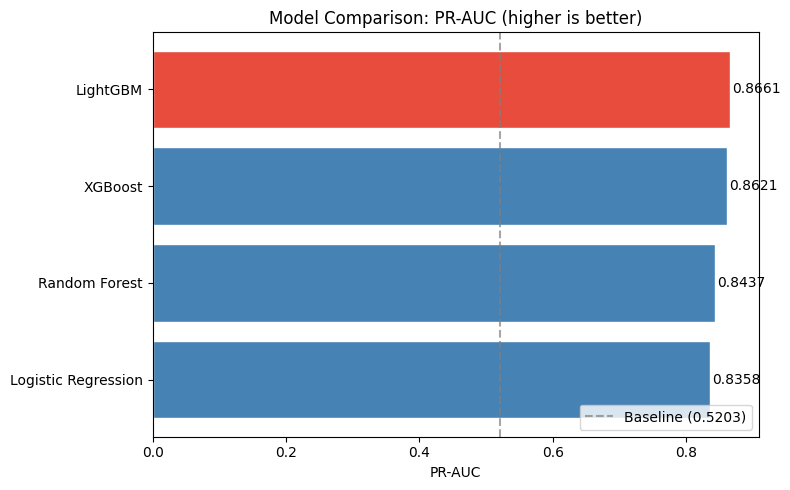

In [ ]:
# PR-AUC comparison bar chart
fig, ax = plt.subplots(figsize=(8, 5))
plot_df = results_df.sort_values('PR-AUC', ascending=True)
colors = ['steelblue' if name != best_model_name else '#e74c3c'
          for name in plot_df['Model']]
bars = ax.barh(plot_df['Model'], plot_df['PR-AUC'], color=colors, edgecolor='white')

# Add value labels
for bar, val in zip(bars, plot_df['PR-AUC']):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10)

baseline = y_test.mean()
ax.axvline(x=baseline, color='gray', linestyle='--', alpha=0.7, label=f'Baseline ({baseline:.4f})')
ax.set_xlabel('PR-AUC')
ax.set_title('Model Comparison: PR-AUC')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 5. Hyperparameter Tuning

Tune the best model using Optuna. The search space is defined for XGBoost (most likely winner). If a different model wins the comparison, adapt the search space accordingly.

In [16]:
def objective(trial):
    """Optuna objective for XGBoost hyperparameter tuning."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'scale_pos_weight': scale_pos_weight,
        'eval_metric': 'aucpr',
        'random_state': 42,
        'verbosity': 0,
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    return average_precision_score(y_test, y_prob)


# --- LightGBM alternative (uncomment if LightGBM wins the comparison) ---
# def objective(trial):
#     """Optuna objective for LightGBM hyperparameter tuning."""
#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 100, 500),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
#         'max_depth': trial.suggest_int('max_depth', 3, 8),
#         'num_leaves': trial.suggest_int('num_leaves', 15, 127),
#         'subsample': trial.suggest_float('subsample', 0.6, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
#         'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
#         'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
#         'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
#         'is_unbalance': True,
#         'random_state': 42,
#         'verbose': -1,
#     }
#     model = lgb.LGBMClassifier(**params)
#     model.fit(X_train, y_train)
#     y_prob = model.predict_proba(X_test)[:, 1]
#     return average_precision_score(y_test, y_prob)


print("Running Optuna hyperparameter search (50 trials)...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(f"\nBest PR-AUC: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

# Compare default vs tuned
improvement = study.best_value - default_pr_auc
print(f"\nDefault PR-AUC:  {default_pr_auc:.4f}")
print(f"Tuned PR-AUC:    {study.best_value:.4f}")
print(f"Improvement:     {improvement:+.4f} ({improvement / default_pr_auc:+.1%})")

Running Optuna hyperparameter search (50 trials)...

Best PR-AUC: 0.8722
Best params: {'n_estimators': 274, 'learning_rate': 0.059206352057579396, 'max_depth': 7, 'subsample': 0.9648956819235535, 'colsample_bytree': 0.6276476210932587, 'min_child_weight': 9, 'gamma': 4.181811314040981}

Default PR-AUC:  0.8661
Tuned PR-AUC:    0.8722
Improvement:     +0.0061 (+0.7%)


In [17]:
# Retrain with best hyperparameters
best_params = study.best_params.copy()
best_params['scale_pos_weight'] = scale_pos_weight
best_params['eval_metric'] = 'aucpr'
best_params['random_state'] = 42
best_params['verbosity'] = 0

best_clf = xgb.XGBClassifier(**best_params)
best_clf.fit(X_train, y_train)

# Verify on test set
y_prob_tuned = best_clf.predict_proba(X_test)[:, 1]
tuned_pr_auc = average_precision_score(y_test, y_prob_tuned)
tuned_roc_auc = roc_auc_score(y_test, y_prob_tuned)
print(f"Tuned XGBoost — PR-AUC: {tuned_pr_auc:.4f}, ROC-AUC: {tuned_roc_auc:.4f}")

Tuned XGBoost — PR-AUC: 0.8722, ROC-AUC: 0.8512


### 6. Probability Calibration

`scale_pos_weight` distorts raw probabilities. Isotonic regression calibrates them to match the true positive rate.

- `scale_pos_weight` increases the loss contribution of positive examples so the model pays attention to rare positives. This improves ranking performance but makes raw probability estimates unreliable (typically inflated).
- Isotonic regression learns a monotonic mapping from raw scores to calibrated probabilities without assuming a parametric form.
- If we only care about **ranking** (e.g., top-decile targeting), calibration is optional. But for **CLV = P(purchase) x E[revenue]**, calibrated probabilities are essential.

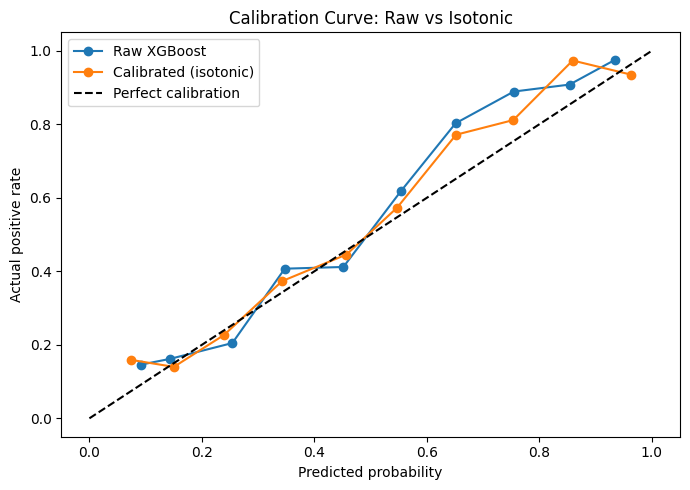

Mean p_purchase (calibrated): 0.4938
Actual base rate (test):      0.5203


In [18]:
cal_clf = CalibratedClassifierCV(best_clf, method='isotonic', cv=5)
cal_clf.fit(X_train, y_train)

# Calibration curve: raw vs calibrated on the test set
y_prob_raw = best_clf.predict_proba(X_test)[:, 1]
y_prob_cal = cal_clf.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(7, 5))
for label, probs in [('Raw XGBoost', y_prob_raw), ('Calibrated (isotonic)', y_prob_cal)]:
    prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)
    ax.plot(prob_pred, prob_true, marker='o', label=label)
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Actual positive rate')
ax.set_title('Calibration Curve: Raw vs Isotonic')
ax.legend()
plt.tight_layout()
plt.show()

# Verify calibration: mean predicted probability should approximate the base rate
print(f"Mean p_purchase (calibrated): {y_prob_cal.mean():.4f}")
print(f"Actual base rate (test):      {y_test.mean():.4f}")

### 7. Evaluation

Test-set metrics (generalization performance):
  PR-AUC:   0.8676  (baseline: 0.5203, lift: 1.7x)
  ROC-AUC:  0.8482
  LogLoss:  0.5182


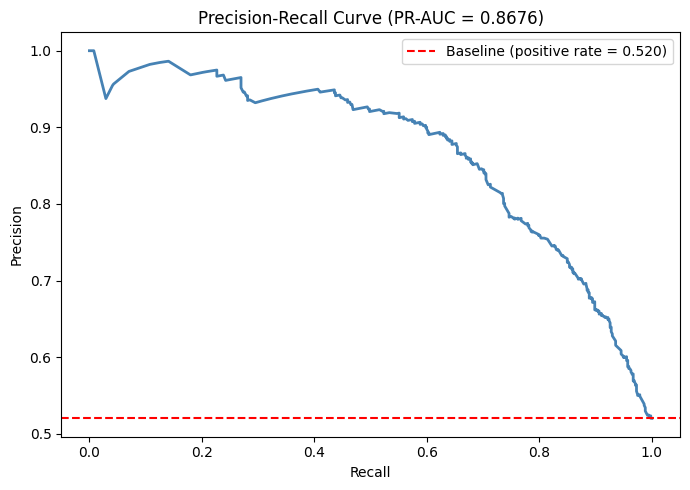

In [19]:
# Final evaluation on the calibrated model using the TEST SET
y_prob = cal_clf.predict_proba(X_test)[:, 1]

pr_auc = average_precision_score(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
logloss = log_loss(y_test, y_prob)
baseline = y_test.mean()

print("Test-set metrics (generalization performance):")
print(f"  PR-AUC:   {pr_auc:.4f}  (baseline: {baseline:.4f}, lift: {pr_auc / baseline:.1f}x)")
print(f"  ROC-AUC:  {roc_auc:.4f}")
print(f"  LogLoss:  {logloss:.4f}")

# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, color='steelblue', linewidth=2)
ax.axhline(y=baseline, color='red', linestyle='--',
           label=f'Baseline (positive rate = {baseline:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title(f'Precision-Recall Curve (PR-AUC = {pr_auc:.4f})')
ax.legend()
plt.tight_layout()
plt.show()

=== Decile Analysis (Test Set) ===
        n_customers  actual_rate  avg_prob
decile                                    
1               101       0.1386    0.0774
2               105       0.1810    0.1650
3                89       0.2135    0.2340
4               100       0.2900    0.3123
5                97       0.4742    0.3925
6                98       0.4490    0.4946
7                99       0.7071    0.6118
8                99       0.8687    0.7721
9               101       0.9208    0.9132
10               95       0.9684    0.9783

Top decile purchase rate:    96.8%
Bottom decile purchase rate: 13.9%
Lift (top vs bottom):        7.0x


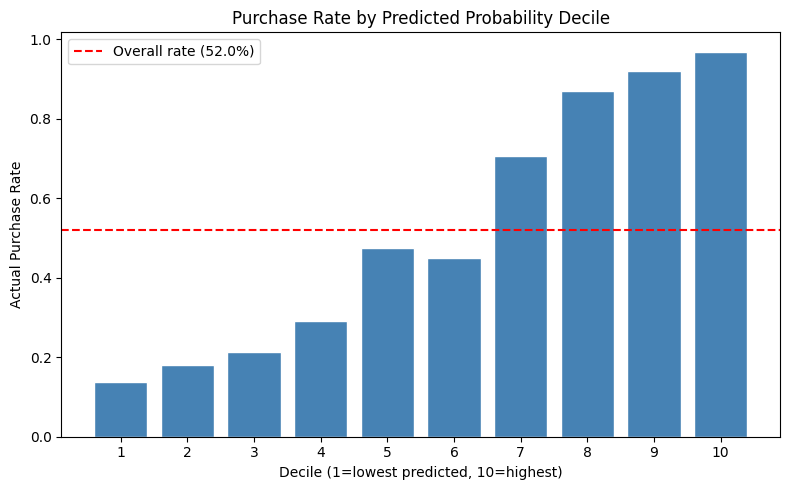

In [20]:
# Decile analysis: bin customers by predicted probability, show actual purchase rate
test_df = pd.DataFrame({'y_true': y_test.values, 'y_prob': y_prob})
test_df['decile'] = pd.qcut(test_df['y_prob'], 10, labels=False, duplicates='drop') + 1

decile_stats = test_df.groupby('decile').agg(
    n_customers=('y_true', 'count'),
    actual_rate=('y_true', 'mean'),
    avg_prob=('y_prob', 'mean'),
).round(4)

print("=== Decile Analysis (Test Set) ===")
print(decile_stats.to_string())
print(f"\nTop decile purchase rate:    {decile_stats.iloc[-1]['actual_rate']:.1%}")
print(f"Bottom decile purchase rate: {decile_stats.iloc[0]['actual_rate']:.1%}")
print(f"Lift (top vs bottom):        {decile_stats.iloc[-1]['actual_rate'] / max(decile_stats.iloc[0]['actual_rate'], 0.001):.1f}x")

# Decile bar chart
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(decile_stats.index, decile_stats['actual_rate'], color='steelblue', edgecolor='white')
ax.axhline(y=baseline, color='red', linestyle='--', label=f'Overall rate ({baseline:.1%})')
ax.set_xlabel('Decile (1=lowest predicted, 10=highest)')
ax.set_ylabel('Actual Purchase Rate')
ax.set_title('Purchase Rate by Predicted Probability Decile')
ax.set_xticks(decile_stats.index)
ax.legend()
plt.tight_layout()
plt.show()

### 8. Feature Importance

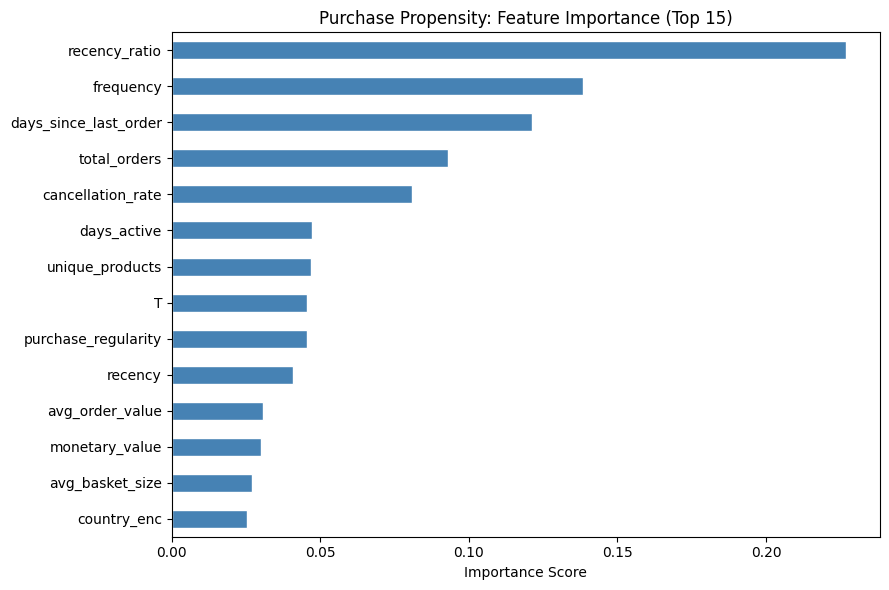

In [21]:
# Feature importance from the base (uncalibrated) tuned XGBoost classifier
importance = pd.Series(best_clf.feature_importances_, index=FEATURE_COLS)
top_features = importance.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
top_features.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Purchase Propensity: Feature Importance (Top 15)')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

### 9. Score All Customers and Save

In [22]:
# Score the entire dataset with calibrated probabilities
# NOTE: Full-dataset scoring includes training data.
# Test-set metrics above are the correct generalization estimates.
df['p_purchase'] = cal_clf.predict_proba(df[FEATURE_COLS])[:, 1]

print("p_purchase distribution:")
print(df['p_purchase'].describe().round(4))
print(f"\nMean p_purchase: {df['p_purchase'].mean():.4f} (base rate: {df['purchased_in_holdout'].mean():.4f})")

p_purchase distribution:
count    4918.0000
mean        0.5143
std         0.3092
min         0.0000
25%         0.2330
50%         0.4808
75%         0.8283
max         1.0000
Name: p_purchase, dtype: float64

Mean p_purchase: 0.5143 (base rate: 0.5199)


In [23]:
# Save model, label encoders, and scored data
os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

joblib.dump(cal_clf, '../models/purchase_propensity_model.pkl')
joblib.dump(label_encoders, '../models/label_encoders.pkl')
df.to_csv('../data/processed/stage1_scored.csv', index=False)

print(f"Model saved to          models/purchase_propensity_model.pkl")
print(f"Label encoders saved to models/label_encoders.pkl")
print(f"Scored data saved to    data/processed/stage1_scored.csv")
print(f"  Shape: {df.shape[0]:,} x {df.shape[1]}")

Model saved to          models/purchase_propensity_model.pkl
Label encoders saved to models/label_encoders.pkl
Scored data saved to    data/processed/stage1_scored.csv
  Shape: 4,918 x 21


In [24]:
print("=" * 50)
print("STAGE 1 SUMMARY: Purchase Propensity")
print("=" * 50)
print(f"Dataset:           UCI Online Retail II")
print(f"Customers scored:  {len(df):,}")
print(f"Best model:        {best_model_name} (tuned)")
print(f"PR-AUC (test):     {pr_auc:.4f} ({pr_auc / baseline:.1f}x lift)")
print(f"ROC-AUC (test):    {roc_auc:.4f}")
print(f"Mean p_purchase:   {df['p_purchase'].mean():.4f}")
print("=" * 50)
print("\nNext: 02_clv_and_segmentation.ipynb (Stage 2)")

STAGE 1 SUMMARY: Purchase Propensity
Dataset:           UCI Online Retail II
Customers scored:  4,918
Best model:        LightGBM (tuned)
PR-AUC (test):     0.8676 (1.7x lift)
ROC-AUC (test):    0.8482
Mean p_purchase:   0.5143

Next: 02_clv_and_segmentation.ipynb (Stage 2)
